In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_sessions = pd.read_csv("data/sessions.csv")
df_events = pd.read_csv("data/events.csv")

print(f"loaded {len(df_events)} events!")
display(df_events.head())

print(f"loaded {len(df_sessions)} sessions!")
display(df_sessions.head())

loaded 6174317 events!


,event_id,session_id,event_timestamp,event_type,viewed_category,android_error
0,019ee0cd-a970-7462-add5-89546c6dba6e,019ee0cbda3c76e2929a9973a7a960f1,2022-12-30 11:16:34,view_item,Furniture and home appliances,NaN
1,019ee0cd-a970-7462-add5-8968041e2260,019ee0cbda3c76e2929a9973a7a960f1,2022-12-30 11:16:35,share,Furniture and home appliances,NaN
2,019ee0cd-a970-7462-add5-89797fa05534,019ee0cbda3c76e2929a9973a7a960f1,2022-12-30 11:17:01,view_item,Beauty and personal care,NaN
3,019ee0cd-a970-7462-add5-898f286e6b9f,019ee0cbda3c76e2929a9973a7a960f1,2022-12-30 11:17:30,view_item_list,Beauty and personal care,NaN
4,019ee0cd-a970-7462-add5-8992fbde59f3,019ee0cbda3c76e2929a9973a7a960f1,2022-12-30 11:17:36,drop_off,Beauty and personal care,ERR_SESSION_TIMEOUT


loaded 1900832 sessions!


,session_id,user_id,session_number,acq_channel,session_start_time,session_date,is_weekend,session_duration_seconds,device_os_version,device_group
0,019ee0cbd9987903b1e82f80611b6406,019ee0cb8de57dd29875083733b31194,1,Facebook,2023-07-09 02:21:07,2023-07-09,True,10,Android 14,Mobile
1,019ee0cbd9987903b1e82f970c3f7b0e,019ee0cb8de57dd298750848541dda8b,1,Organic,2023-02-02 12:21:55,2023-02-02,False,69,Android 12,Mobile
2,019ee0cbd9987903b1e82fa2405519da,019ee0cb8de57dd298750852b367a53c,1,TikTok,2023-06-09 17:48:20,2023-06-09,False,284,Android 13,Mobile
3,019ee0cbd9987903b1e82fb0d6eec71d,019ee0cb8de57dd29875086cf61ecbde,1,Organic,2023-02-13 00:32:58,2023-02-13,False,162,macOS Ventura,Desktop
4,019ee0cbd9987903b1e82fcf24af10ed,019ee0cb8de57dd29875087c319c0bfc,1,Organic,2023-10-12 16:02:36,2023-10-12,False,83,macOS Ventura,Desktop


In [2]:
funnel_counts = df_events['event_type'].value_counts()

print("Raw Event Counts:")
display(funnel_counts)

Raw Event Counts:


event_type
view_item            2580645
add_to_cart           770280
view_item_list        625634
drop_off              623290
view_cart             369438
select_item           329098
add_to_wishlist       210520
begin_checkout        166610
search                109439
share                 105303
add_shipping_info     104389
add_payment_info       76136
purchase               58874
remove_from_cart       33310
generate_lead          10793
refund                   558
Name: count, dtype: int64

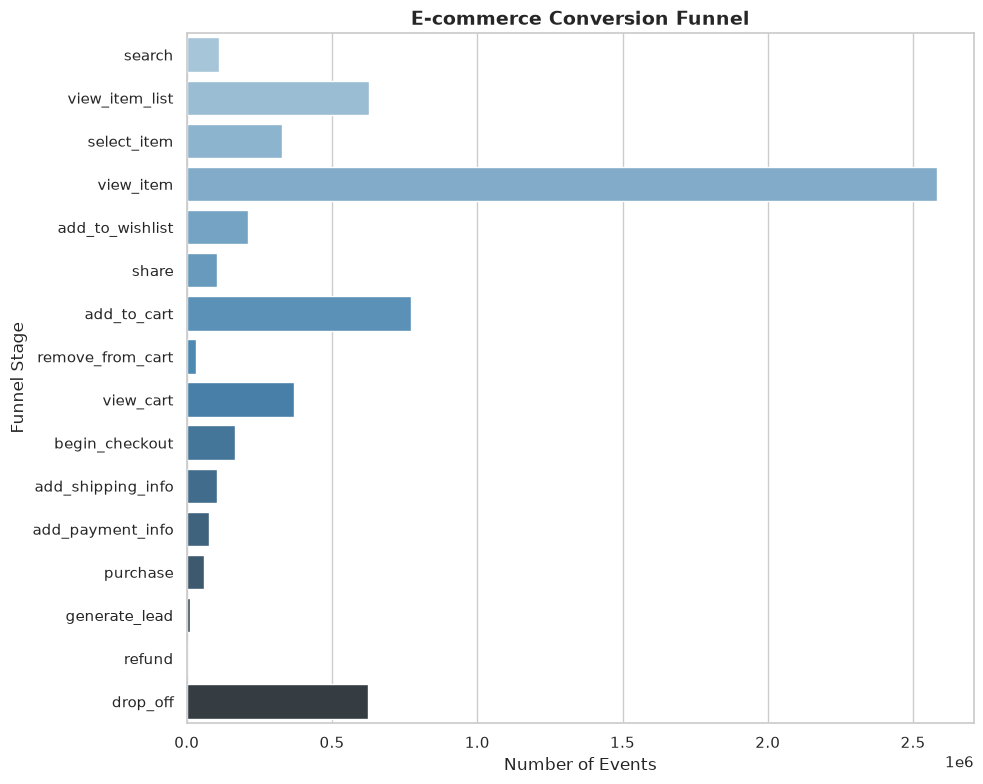

In [3]:
funnel_order = ["search", "view_item_list", "select_item", "view_item", "add_to_wishlist", "share", "add_to_cart", "remove_from_cart", "view_cart", "begin_checkout", "add_shipping_info", "add_payment_info", "purchase", "generate_lead", "refund", "drop_off"] 

ordered_funnel = funnel_counts.reindex(funnel_order)
plt.figure(figsize=(10, 8)) 

sns.barplot(
    x=ordered_funnel.values, 
    y=ordered_funnel.index, 
    hue=ordered_funnel.index, 
    palette="Blues_d", 
    legend=False
)

plt.title("E-commerce Conversion Funnel", fontsize=14, fontweight='bold')
plt.xlabel("Number of Events", fontsize=12)
plt.ylabel("Funnel Stage", fontsize=12)
plt.tight_layout()
plt.show()

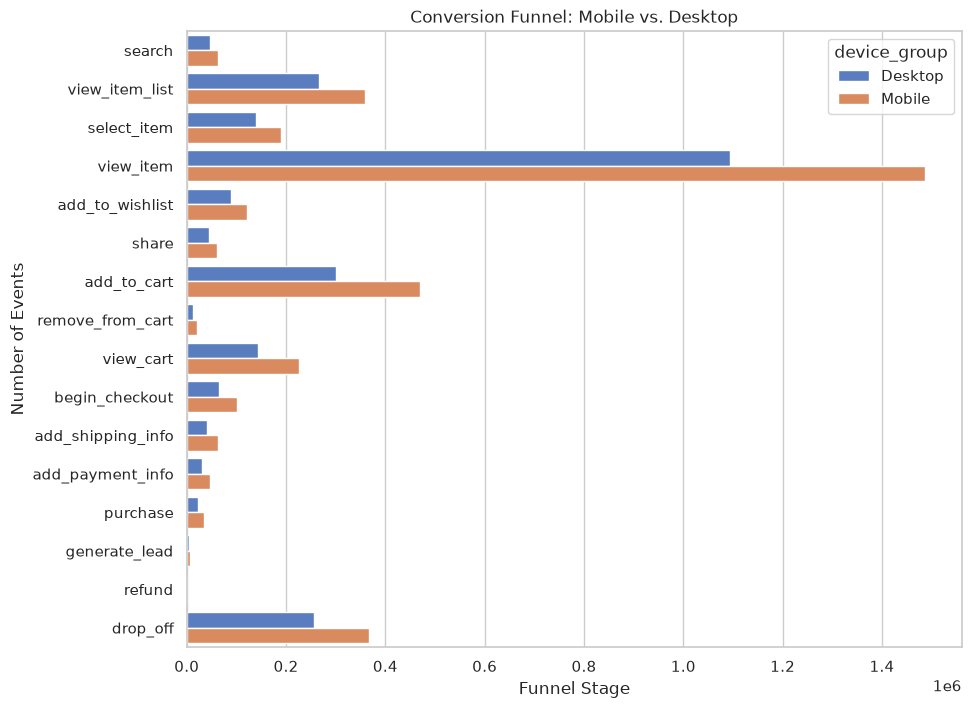

In [4]:
df_merged = df_events.merge(df_sessions[['session_id', 'device_group']], on='session_id', how='left')

device_funnel = df_merged.groupby(['device_group', 'event_type']).size().reset_index(name='count')

plt.figure(figsize=(10, 8))
sns.barplot(
    data=device_funnel, 
    x='count', 
    y='event_type', 
    hue='device_group', 
    order=funnel_order, 
    palette="muted"
)
plt.title("Conversion Funnel: Mobile vs. Desktop")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()

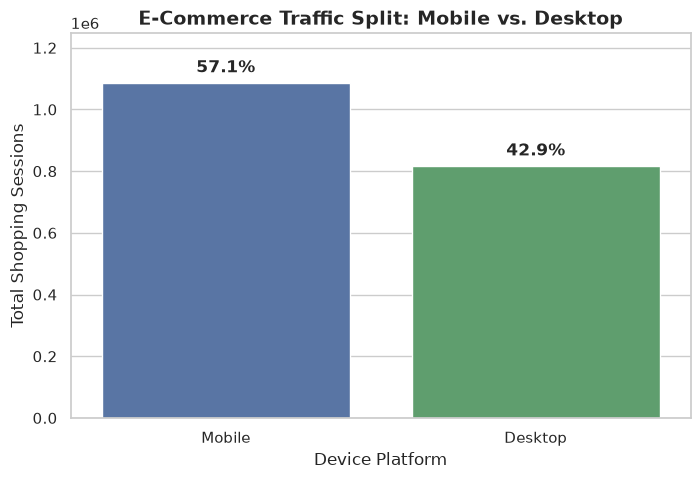

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device_traffic = df_sessions['device_group'].value_counts().reset_index()
device_traffic.columns = ['device_group', 'session_count']

total_sessions = device_traffic['session_count'].sum()
device_traffic['percentage'] = (device_traffic['session_count'] / total_sessions) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=device_traffic, 
    x='device_group', 
    y='session_count',
    hue='device_group', 
    palette=['#4C72B0', '#55A868',]
)

for i, p in enumerate(ax.patches):
    percentage_text = f"{device_traffic['percentage'].iloc[i]:.1f}%"
    ax.annotate(
        percentage_text, 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=12, fontweight='bold', 
        xytext=(0, 5), textcoords='offset points'
    )

plt.title("E-Commerce Traffic Split: Mobile vs. Desktop", fontsize=14, fontweight='bold')
plt.ylabel("Total Shopping Sessions", fontsize=12)
plt.xlabel("Device Platform", fontsize=12)
plt.ylim(0, device_traffic['session_count'].max() * 1.15)
plt.show()